In [1]:
import numpy as np
from numba.core.types import none
from numba.np.arrayobj import np_arange

from main_functions import *
import matplotlib.pyplot as plt

recording_path = r"data\2026-02-25_mb_fish1_rec2"
save_path = r"results\2026-02-25_mb_fish1_rec2"

fluorescence, recording, phase, ca_rec_group_id_fun = digest_folder(recording_path, plane=0)
process_recording(recording, phase, radial_bin_num=16)



In [3]:
Dff_all_neuron = np.load(os.path.join(save_path, "deconvolved_Dff_original.npy"))
Dff_resampled = scipy.interpolate.interp1d(recording['ca_times'], Dff_all_neuron, kind='nearest')(
        recording['time_resampled'])

In [4]:
# sample first neuron from loop (over all neurons)
i=0
test_neuron_dff = Dff_resampled[i, :]

# einfacher als mit GMMs (wie's in 2019 paper is), robust
detect_events_with_derivative(recording, test_neuron_dff)

In [5]:
|Dff_all_neuron.shape

SyntaxError: invalid syntax (3089923136.py, line 1)

# calculate reverse correlation function

In [ ]:
# ETA berechnung, Abb mit cnts für bewegungsrichtugen im vf
bootstrap_num=1000

# ROI data
test_neuron_signal_selection = recording['signal_selection'] # timepoints mask giving events
# Recording data
sample_rate = recording['sample_rate']
radial_bin_edges = recording['radial_bin_edges']
cmn_phase_selection = recording['cmn_phase_selection'] # timepoints mask giving CMN stim
motion_vectors_2d = recording['cmn_motion_vectors_2d']

motion_vectors_2d_filtered = motion_vectors_2d[test_neuron_signal_selection, :, :]
radial_bin_norms, radial_bin_etas = calculate_local_directions(motion_vectors_2d_filtered, radial_bin_edges)

recording[f'radial_bin_etas'] = radial_bin_etas # ETA's`
recording[f'radial_bin_norms'] = radial_bin_norms

min_frame_shift = 4 * sample_rate
max_frame_shift = int(cmn_phase_selection.sum() - min_frame_shift)
frame_shifts = np.random.randint(min_frame_shift, max_frame_shift, size=(bootstrap_num))

signal_within_cmn_selection = test_neuron_signal_selection[cmn_phase_selection]
signal_indices = signal_within_cmn_selection.nonzero()[0][:,None]


In [ ]:
idcs=np.mod(signal_indices + frame_shifts, signal_within_cmn_selection.size).T
idcs.shape, idcs[0].shape

In [ ]:
mv=motion_vectors_2d[cmn_phase_selection]

angles=np.arctan2(mv[:,:,0], mv[:,:,1])
velocities=np.linalg.norm(mv, axis=2)
mv.shape, angles.shape, velocities.shape

In [ ]:
vel=velocities[idcs[0]]
ang=angles[idcs[0]]
bins=radial_bin_edges
vel.shape, ang.shape, bins.shape

In [ ]:
bins[:-1].shape, ang[:, :, None].shape, vel[:, :, None].shape

In [ ]:
mv=mv[idcs[0]]

In [ ]:
# ang=np.arctan2(mv[:,:,0], mv[:,:,1])
# vel=np.linalg.norm(mv, axis=2)
# np.mean(vel[:, :, None] * np.logical_and(bins[:-1] <= ang[:, :, None], ang[:, :, None] <= bins[1:]), axis=0)

In [ ]:
norms = vel[:,  :, None] * np.logical_and(bins[:-1] <= ang[:,  :, None], ang[:, :, None] <= bins[1:])
etas=norms.mean(axis=0)

In [ ]:
etas.shape

In [ ]:
etas

In [ ]:
# radial_bin_bs_etas = np.zeros((bootstrap_num,) + radial_bin_etas.shape)
# bins = radial_bin_bs_etas
# for s in tqdm(range(bootstrap_num)):
#         # Circularly permutate signal
#         ### perm_signal_selection = np.roll(signal_within_cmn_selection, frame_shifts[s])
#
#         # Get motion vectors of permutated signal
#         bs_motion_vectors = motion_vectors_2d[cmn_phase_selection][perm_signal_selection]
#
#         # Calculate vector ETAs for each local radial bin
          # REPLACED BELOW
#         #radial_bin_bs_etas[s] = calculate_local_directions(bs_motion_vectors, radial_bin_edges)[1]
#
#         motion_angles = np.arctan2(bs_motion_vectors[:, :, 1], bs_motion_vectors[:, :, 0])
#         motion_velocities = np.linalg.norm(bs_motion_vectors, axis=2)
#         from numpy import newaxis
#         bin_norms = motion_velocities[:, :, newaxis] * np.logical_and(radial_bin_edges[:-1] <= motion_angles[:, :, newaxis], motion_angles[:, :, newaxis] <= radial_bin_edges[1:])
#         radial_bin_bs_etas[s] = np.mean(bin_norms, axis=0)
#
# recording[f'radial_bin_bs_etas'] = radial_bin_bs_etas

### functions

In [ ]:
# def calculate_local_directions(motvecs: np.ndarray, bin_edges: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
#     # Convert to angle and velocity
#     motion_angles = np.arctan2(motvecs[:, :, 1], motvecs[:, :, 0])
#     motion_velocities = np.linalg.norm(motvecs, axis=2)
#     # Backwards transform (keep for reference):
#     # motion_vectors_2d = np.zeros((*motion_angles.shape[:2], 2))
#     # motion_vectors_2d[:,:,0] = motion_velocities * np.cos(motion_angles)
#     # motion_vectors_2d[:,:,1] = motion_velocities * np.sin(motion_angles)
#
#     # Calculate bin vectors for each patch and frame weighted by the local velocities
#     bin_norms = motion_velocities[:, :, None] * np.logical_and(bin_edges[:-1] <= motion_angles[:, :, None],
#                                                                motion_angles[:, :, None] <= bin_edges[1:])
#
#     # Calculate ETAs
#     bin_etas = np.mean(bin_norms, axis=0)
#
#     return bin_norms, bin_etas

# compare results to original pipeline results

In [ ]:
import pickle

In [ ]:
with open('radial_bin_etas.npy', 'rb') as f:
    radial_bin_etas = np.load(f)


with open('radial_bin_etas_slow.pkl', 'rb') as f:
    radial_bin_etas_slow = pickle.load(f)

etas, etas_ = radial_bin_etas, radial_bin_etas_slow
etas.shape, etas_.shape

In [ ]:
error=np.sum(radial_bin_etas - radial_bin_etas_slow)
error/ radial_bin_etas.sum() , error/radial_bin_etas_slow.sum()

# run full pipeline for one neuron

In [ ]:
# einfacher als mit GMMs (wie's in 2019 paper is), robust
detect_events_with_derivative(recording, test_neuron_dff)

# Calcium-event-triggered-averages berechnung
calculate_reverse_correlations_shm(recording, bootstrap_num=1024)

# 1. Teil Bootstrap test, bootstrap verteilung berechnungen, welche revcorr significant
calculate_directional_significance(recording)

# added by me: 2. Teil
calculate_directional_preference(recording)

# clusteranalyse
find_clusters(recording)

# cluster based statistics, (2-step NP bootsrap test)
calculate_cluster_significances(recording)

plot_rf_overview(recording, i, save_path)

In [ ]:
f'test{str(1)}'

# inspect recording dict

In [ ]:
save_path

In [6]:
import pickle
with open(os.path.join(recording_path, 'recording_dicts', f'recording_neuron{str(i)}.pkl'), 'rb') as f:
    recording = pickle.load(f)

In [ ]:
recording.keys()

In [ ]:
recording['radial_bin_bs_etas'].shape, recording['radial_bin_bs_etas'].shape

In [ ]:
p=recording['radial_bin_p_values']

In [ ]:
plt.hist(p.flatten(), bins=200);
np.sum(p<.05), p.size

In [ ]:
np.any(p>.05, axis=1).sum()

In [ ]:
recording['radial_bin_significances']

# fitting optic flow field

scipy minimize, dont care about values, since only angles count.
define rotation axis: azimuth angle, elevation angle



In [7]:
radial_bin_centers=recording['radial_bin_centers']
radial_bin_centers

array([-2.94524311, -2.55254403, -2.15984495, -1.76714587, -1.37444679,
       -0.9817477 , -0.58904862, -0.19634954,  0.19634954,  0.58904862,
        0.9817477 ,  1.37444679,  1.76714587,  2.15984495,  2.55254403,
        2.94524311])

In [9]:
positions=recording['positions']
positions.shape

(320, 3)

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(projection='3d')
ax.scatter(recording['positions'][:,0],recording['positions'][:,1],recording['positions'][:,2])
ax.scatter(0,0,0)
plt.show()

In [201]:
def tof(angle_azimuth: float, angle_elevation: float, positions: np.ndarray):
    """
        Translational optic flow field.
        Returns a translational optic flow field for a given translation axis.

        Parameters:
            angle_azimuth (float):
                angle in radians of the azimuth of the translation axis.
            angle_elevation (float):
                angle in radians of the elevation of the translation axis.
            positions (np.array):
                3D positions to sample flow field at.

        Returns:
            F (np.array):
                Return values of optic flow field (3D vector) at each point
                given in positions.
            FoC, FoE (np.array):
                Focus of Expansion and Focus of Contraction of the optic flow field.
                Given as 3D unit vector.
    """
    from numpy import sin, cos
    axis, a, b = np.array([1,0,0]), angle_azimuth, angle_elevation
    # yaw and pitch rotation matrices
    yaw=np.array([[cos(a),-sin(a),0],[sin(a), cos(a), 0],[0,0,1]])
    pitch=np.array([[cos(b), 0, sin(b)],[0,1,0],[-sin(b), 0, cos(b)]])
    T=axis @ yaw @ pitch
    return T - np.dot(P, T)[:,None] * P

def rof(angle_azimuth: float, angle_elevation: float, positions: np.ndarray):
    """
        Rotational optic flow field.
        Returns a rotation optic flow field for a given translation axis.

        Parameters:
            angle_azimuth (float):
                angle in radians of the azimuth of the rotation axis.
            angle_elevation (float):
                angle in radians of the elevation of the rotation axis.
            positions (np.array):
                3D positions to sample flow field at.

        Returns:
            F (np.array):
                Return values of optic flow field (3D vector) at each point
                given in positions.
            FoC, FoE (np.array):
                Focus of Expansion and Focus of Contraction of the optic flow field.
                Given as 3D unit vector.
    """
    from numpy import sin, cos
    axis, a, b = np.array([1,0,0]), angle_azimuth, angle_elevation
    # yaw and pitch rotation matrices
    yaw=np.array([[cos(a),-sin(a),0],[sin(a), cos(a), 0],[0,0,1]])
    pitch=np.array([[cos(b), 0, sin(b)],[0,1,0],[-sin(b), 0, cos(b)]])
    return -np.cross(positions, axis @ yaw @ pitch)

In [206]:
TOF=tof(0, np.pi/4, positions)
positions=recording['positions']
TOF.shape, positions.shape

((320, 3), (320, 3))

In [219]:
# plot in 3D
ax = plt.figure().add_subplot(projection='3d')
ax.quiver(positions[:,0], positions[:,1], positions[:,2], TOF[:,0], TOF[:,1], TOF[:,2], length=0.2)
ax.set_zlabel('elevation[deg]')

Text(0.5, 0, 'elevation[deg]')

In [ ]:
# plot in 2D
from main_functions import project_to_local_2d_vectors
from plotting_functions import cart2sph
import matplotlib
from scipy.optimize import minimize

In [433]:
# use 2D projections to calculate RSS_angle
# if theres time, do this while still n 3D coordinated exclude potential artifacts from the 2D projection

In [472]:
def RSSangle(F, E):
    """
        Calculate RSS (residual sum of squared) of angles between two vector fields.
        Used in this analysis to calculate RSS between estimated RF and optic flow field,
        as an error function to fit the latter to the former.
        Parameters:
            F (np.array):
                Optic flow field to fit.
            E (np.array):
                Estimated RF.
        Returns:
            RSS (float)
    """
    #print(E)
    coeffcients = np.sum(F*E, axis=1)/ (np.linalg.norm(np.clip(E, 0.0000001, 1.), axis=1)* np.linalg.norm(F, axis=1))
    angles = np.arccos(np.clip(coeffcients, -1.0, 1.0))
    return np.sum(angles**2)

def RSSangle_wrapper(F, E):
    """
        Wraps around def RSSangle(F, E) to transform F from 3D to 2D,
        for convenience in using it with scipy.optimize.minimize
    """
    F=project_to_local_2d_vectors(positions, F[None,:,:]).squeeze()
    return RSSangle(F, E)


In [473]:
E = recording['preferred_vectors'] # RF estimation from ETAs

F=project_to_local_2d_vectors(positions, tof(1.,0., positions)[None,:,:]).squeeze()

np.sum(F*E, axis=1)/ (np.linalg.norm(E, axis=1)* np.linalg.norm(F, axis=1))

C:\Users\mbardelang\AppData\Local\Temp\ipykernel_8200\3904492244.py:5: RuntimeWarning: invalid value encountered in divide
  np.sum(F*E, axis=1)/ (np.linalg.norm(E, axis=1)* np.linalg.norm(F, axis=1))


array([-0.20676696, -0.99233516, -0.05525283, -0.61217162, -0.89127296,
       -0.97862538, -0.95674372, -0.99272898, -0.39706887, -0.76653944,
       -0.97178106, -0.88448287, -0.80226992, -0.98597332, -0.54692556,
       -0.90402698,  0.998126  ,  0.41243378,  0.00104792,  0.97181958,
        0.63643697,  0.93774932, -0.82984612,  0.46582401,  0.07193839,
        0.29313429,  0.51832056, -0.6134082 , -0.84641208,  0.8237764 ,
        0.31290933,  0.28361771, -0.53688168, -0.70784739, -0.81610418,
        0.39680656, -0.05424669, -0.06979144, -0.63014673, -0.14970745,
        0.95450611, -0.62514942, -0.97546213, -0.57216984, -0.4766915 ,
       -0.51553004, -0.7374208 , -0.88037481,         nan,  0.33221046,
        0.90110761,  0.23686769, -0.53030758, -0.26706094, -0.59101929,
       -0.58118607, -0.30917288, -0.14070363,  0.51190566, -0.99738782,
       -0.90753238, -0.54991376,  0.25973872, -0.17123897,  0.98078528,
        0.48655337, -0.98066313,  0.83146961,  0.00635849,  0.10

In [474]:
positions=recording['positions']
E = recording['preferred_vectors'] # RF estimation from ETAs

mini=minimize(
    lambda angles: RSSangle_wrapper(tof(*angles, positions), E),
    [0., 0.],
)

F_3D=tof(*mini.x, positions)[None,:,:]
F=project_to_local_2d_vectors(positions, F_3D).squeeze()


In [479]:
mini

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 847.2520379743728
        x: [-4.587e-01 -1.831e-01]
      nit: 23
      jac: [ 1.603e+00 -1.733e+00]
 hess_inv: [[ 2.412e-04 -4.015e-05]
            [-4.015e-05  1.049e-04]]
     nfev: 342
     njev: 110

In [482]:
# Plot DFF
gs_cmn = plt.GridSpec(20, 10)
fig_cmn = plt.figure(figsize=(20, 10))
# Plot preferred local motion vectors quiver plot
ax_quiv = fig_cmn.add_subplot(gs_cmn[:, :])
# Get position and local motion preference data
x, y, _ = cart2sph(*positions.T)

Evels=np.linalg.norm(E, axis=1)
color = matplotlib.colormaps['tab20'](0)
ax_quiv.quiver(x, y, E[:, 0], E[:, 1],
               pivot='mid', color=color, width=0.002, scale=Evels.max() * 30)

Fvels=np.linalg.norm(F, axis=1)
color = matplotlib.colormaps['tab20'](2)
ax_quiv.quiver(x, y, F[:, 0], F[:, 1],
               pivot='mid', color=color, width=0.002, scale=Fvels.max() * 30)

ax_quiv.set_xlabel('azimuth [deg]')
ax_quiv.set_ylabel('elevation [deg]')
ax_quiv.set_aspect('equal')

In [483]:
recording['signal_selection']

array([False, False, False, ..., False, False, False], shape=(33099,))

# inspect coordinate system

In [29]:
normals=recording['positions']
vectors=recording['cmn_motion_vectors_3d']
normals.shape, vectors.shape

((320, 3), (33099, 320, 3))

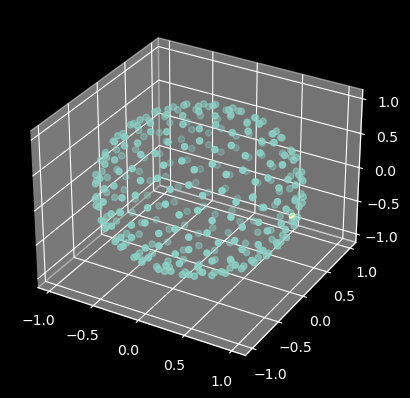

In [47]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x-axis: left-right, y=axis: fore-back, z=axis: up-down
ax.scatter(recording['positions'][:, 0], recording['positions'][:, 1], recording['positions'][:, 2])

#ax.scatter(0, 0, 0)
# assume the fishs FOV is centered here
ax.scatter(1, 0, 0)

plt.show()

In [30]:
# vectical norms
vnorms = np.array([0, 0, 1]) - normals * np.dot(normals, np.array([0, 0, 1]))[:, None]
vnorms.shape

(320, 3)

In [32]:
np.dot(normals, np.array([0, 0, 1]))[:, None].shape

(320, 1)

In [44]:
vnorms /= np.linalg.norm(vnorms, axis=1)[:, None]

# horizontal norms
hnorms = -crossproduct(vnorms, normals)
hnorms /= np.linalg.norm(hnorms, axis=1)[:, None]

vectors_2d = np.zeros((*vectors.shape[:2], 2))
for i, v in enumerate(vectors):
    # Calculate 2d motion vectors in coordinate system defined by local horizontal and vertical norms
    motvecs_2d = np.array([np.sum(v * hnorms, axis=1),
                           np.sum(v * vnorms, axis=1)])
    vectors_2d[i] = motvecs_2d.T